# <center>Recurrent Neural Networks</center>
## <center>Inclass Project 3 - MA4144</center>

This project contains multiple tasks to be completed, some require written answers. Questions that required written answers are given in blue fonts. Almost all written questions are open ended, they do not have a correct or wrong answer. You are free to give your opinions, but please provide related answers within the context.

After finishing project run the entire notebook once and **save the notebook as a pdf** (File menu -> Save and Export Notebook As -> PDF). You are **required to upload both this ipynb file and the PDF on moodle**.

***

## Outline of the project

The aim of the project is to build a RNN model to suggest autocompletion of half typed words. You may have seen this in many day today applications; typing an email, a text message etc. For example, suppose you type in the four letter "univ", the application may suggest you to autocomplete it by "university".

![Autocomplete](https://d33v4339jhl8k0.cloudfront.net/docs/assets/5c12e83004286304a71d5b72/images/66d0cb106eb51e63b8f9fbc6/file-gBQe016VYt.gif)

We will train a RNN to suggest possible autocompletes given $3$ - $4$ starting letters. That is if we input a string "univ" hopefully we expect to see an output like "university", "universal" etc.

For this we will use a text file (wordlist.txt) containing 10,000 common English words (you'll find the file on the moodle link). The list of words will be the "**vocabulary**" for our model.

We will use the Python **torch library** to implement our autocomplete model. 

***


Use the below cell to use any include any imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## Section 1: Preparing the vocabulary

In [3]:
WORD_SIZE = 13

**Q1.** In the following cell provide code to load the text file (each word is in a newline), then extract the words (in lowercase) into a list.

For practical reasons of training the model we will only use words that are longer that $3$ letters and that have a maximum length of WORD_SIZE (this will be a constant we set at the beginning - you can change this and experiment with different WORD_SIZEs). As seen above it is set to $13$.

So out of the extracted list of words filter out those words that match our criteria on word length.

To train our model it is convenient to have words/strings of equal length. We will choose to convert every word to length of WORD_SIZE, by adding underscores to the end of the word if it is initially shorter than WORD_SIZE. For example, we will convert the word "university" (word length 10) into "university___" (wordlength 13). In your code include this conversion as well.

Store the processed WORD_SIZE lengthed strings in a list called vocab.

In [4]:
# Load words from file
with open('wordlist.txt', 'r', encoding='utf-8') as f:
    words = [line.strip().lower() for line in f.readlines()]

# Define helper functions for word processing
def is_valid_length(term):
    return 3 < len(term) <= WORD_SIZE

def pad_word(term):
    return term + '_' * (WORD_SIZE - len(term))

# Process vocabulary: filter by length then apply padding
valid_words = []
for word in words:
    if is_valid_length(word):
        valid_words.append(word)

vocab = []
for word in valid_words:
    padded_word = pad_word(word)
    vocab.append(padded_word)

# Display results
print(f"Loaded {len(words)} words")
print(f"Vocabulary after filtering/padding: {len(vocab)}")
vocab

Loaded 10000 words
Vocabulary after filtering/padding: 8847


['aaron________',
 'abandoned____',
 'aberdeen_____',
 'abilities____',
 'ability______',
 'able_________',
 'aboriginal___',
 'abortion_____',
 'about________',
 'above________',
 'abraham______',
 'abroad_______',
 'absence______',
 'absent_______',
 'absolute_____',
 'absolutely___',
 'absorption___',
 'abstract_____',
 'abstracts____',
 'abuse________',
 'academic_____',
 'academics____',
 'academy______',
 'accent_______',
 'accept_______',
 'acceptable___',
 'acceptance___',
 'accepted_____',
 'accepting____',
 'accepts______',
 'access_______',
 'accessed_____',
 'accessibility',
 'accessible___',
 'accessing____',
 'accessories__',
 'accessory____',
 'accident_____',
 'accidents____',
 'accommodate__',
 'accommodation',
 'accompanied__',
 'accompanying_',
 'accomplish___',
 'accomplished_',
 'accordance___',
 'according____',
 'accordingly__',
 'account______',
 'accounting___',
 'accounts_____',
 'accreditation',
 'accredited___',
 'accuracy_____',
 'accurate_____',
 'accurate

<font color='blue'>In the above explanation it was mentioned "for practical reasons of training the model we will only use words that are longer that $3$ letters and that have a certain maximum length". In your opinion what could be those practical? Will hit help to build a better model?</font>

**Answer** 

#### Reasons for Filtering Words by Length:

1. **Reduce Noise**: 
   - Short words (like "a" or "I") don't carry much semantic meaning.
   - Long words are rare and complex, which can add unnecessary noise.

2. **Improve Efficiency**: 
   - Smaller vocabulary leads to faster training and reduced memory usage.

3. **Enhance Generalization**: 
   - Focusing on medium-length words prevents overfitting to rare words and allows the model to learn more generalizable patterns.

4. **Control Vocabulary Size**: 
   - Ensures the model doesn’t handle an unmanageable vocabulary, improving model performance.

Filtering words by length **helps build a better model** by improving efficiency, generalization, and reducing complexity.


**Q2** To input words into the model, we will need to convert each letter/character into a number. as we have seen above, the only characters in our list vocab will be the underscore and lowercase english letters. so we will convert these $27$ characters into numbers as follows: underscore -> $0$, 'a' -> $1$, 'b' -> $2$, $\cdots$, 'z' -> $26$. In the following cell,

(i) Implement a method called char_to_num, that takes in a valid character and outputs its numerical assignment.

(ii) Implement a method called num_to_char, that takes in a valid number from $0$ to $26$ and outputs the corresponding character.

(iii) Implement a method called word_to_numlist, that takes in a word from our vocabulary and outputs a (torch) tensor of numbers that corresponds to each character in the word in that order. For example: the word "united_______" will be converted to tensor([21, 14,  9, 20,  5,  4,  0,  0,  0,  0,  0,  0,  0]). You are encouraged to use your char_to_num method for this.

(iv) Implement a method called numlist_to_word, that does the opposite of the above described word_to_numlist, given a tensor of numbers from $0$ to $26$, outputs the corresponding word. You are encouraged to use your  num_to_char method for this.

Note: As mentioned since we are using the torch library we will be using tensors instead of the usual python lists or numpy arrays. Tensors are the list equivalent in torch. Torch models only accept tensors as input and they output tensors.

In [5]:
def char_to_num(char):
    if char == '_':
        num = 0
    elif 'a' <= char <= 'z':
        num = ord(char) - ord('a') + 1
    else:
        raise ValueError(f"Invalid character: {char}")
    
    return(num)

def num_to_char(num):
    if num == 0:
        char = '_'
    elif 1 <= num <= 26:
        char = chr(num - 1 + ord('a'))
    else:
        raise ValueError(f"Invalid number: {num}")
    return(char)

def word_to_numlist(word):
    numlist = torch.tensor(list(map(char_to_num, word)), dtype=torch.long)
    return(numlist)

def numlist_to_word(numlist):
    word = ''.join(map(lambda x: num_to_char(x.item()), numlist))
    return(word)

def vocab_to_tensor(vocab_list):
    """Convert entire vocabulary to tensor format efficiently"""
    return torch.stack([word_to_numlist(word) for word in vocab_list])

vocab_tensors = vocab_to_tensor(vocab)
print(f"Vocabulary converted to tensor format: {vocab_tensors.shape}")

Vocabulary converted to tensor format: torch.Size([8847, 13])


<font color='blue'>We convert letter into just numbers based on their aphabetical order, I claim that it is a very bad way to encode data such as letters to be fed into learning models, please write your explanation to or against my claim. If you are searching for reasons, the keyword 'categorical data' may be useful. Although the letters in our case are not treated as categorical data, the same reasons as for categorical data is applicable. Even if my claim is valid, at the end it won't matter due to something called "embedding layers" that we will use in our model. What is an embedding layer? What is it's purpose? Explain.</font> (write answers in the cell below as a string)

In [14]:
#Write answer here as strings:

answer_ = """
The claim is valid - encoding letters based on alphabetical order is indeed a problematic approach for machine learning models. Here's why:

1. **Artificial Ordering**: Assigning 'a'=1, 'b'=2, etc. implies that 'b' is somehow "greater" than 'a', which creates false mathematical relationships between characters that don't exist in natural language.

2. **Distance Misrepresentation**: The model might interpret that 'a' and 'c' are more similar than 'a' and 'z' simply because their numerical values are closer, which is linguistically meaningless.

3. **Categorical Nature**: Letters are categorical data, not ordinal. There's no inherent ranking or numerical relationship between them.

However, this issue is resolved by **embedding layers**. An embedding layer is a trainable lookup table that converts discrete tokens (like our character numbers) into dense, continuous vector representations. 

**Purpose of Embedding Layers:**
- Transform sparse, one-hot encoded inputs into dense vectors
- Learn meaningful relationships between characters during training
- Allow the model to discover that certain characters frequently appear together or in similar contexts
- Convert categorical data into a continuous space where mathematical operations make sense

The embedding layer essentially learns a better representation than our naive alphabetical encoding, making the initial encoding scheme irrelevant to the final model performance.
"""

## Section 2: Implementing the Autocomplete model

We will implement a RNN LSTM model. The [video tutorial](https://www.youtube.com/watch?v=tL5puCeDr-o) will be useful. Our model will be only one hidden layer, but feel free to sophisticate with more layers after the project for your own experiments.

Our model will contain all the training and prediction methods as single package in a class (autocompleteModel) we will define and implement below.

In [7]:
LEARNING_RATE = 0.005

In [8]:
class autocompleteModel(nn.Module):

    #Constructor
    def __init__(self, alphabet_size, embed_dim, hidden_size, num_layers):
        super().__init__()

        #Set the input parameters to self parameters
        self.alphabet_size = alphabet_size
        self.embed_dim = embed_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        #Initialize the layers in the model:
        #1 embedding layer, 1 - LSTM cell (hidden layer), 1 fully connected layer with linear activation
        self.embedding = nn.Embedding(alphabet_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, alphabet_size)

    #Feedforward
    def forward(self, character, hidden_state, cell_state):

        #Perform feedforward in order
        #1. Embed the input (one charcter represented by a number)
        #2. Feed the embedded output to the LSTM cell
        #3. Feed the LSTM output to the fully connected layer to obtain the output
        #4. return the output, and both the hidden state and cell state from the LSTM cell output
        
        # Embed the input character - character should be a single value
        embedded = self.embedding(character.unsqueeze(0).unsqueeze(0))  # Shape: (1, 1, embed_dim)
        
        # Feed to LSTM cell
        lstm_out, (hidden_state, cell_state) = self.lstm(embedded, (hidden_state, cell_state))
        
        # Feed to fully connected layer
        output = self.fc(lstm_out.squeeze(0).squeeze(0))  # Remove sequence and batch dimensions
        
        return output, hidden_state, cell_state

    #Intialize the first hidden state and cell state (for the start of a word) as zero tensors of required length.
    def initial_state(self):
        
        h0 = torch.zeros(self.num_layers, 1, self.hidden_size)
        c0 = torch.zeros(self.num_layers, 1, self.hidden_size)
        
        return (h0, c0)

    #Train the model in epochs given the vocab, the training will be fed in batches of batch_size
    def trainModel(self, vocab, epochs = 5, batch_size = 100):

        #Convert the model into train mode
        self.train()

        #Set the optimizer (ADAM), you may need to provide the model parameters and learning rate
        optimizer = optim.Adam(self.parameters(), lr=LEARNING_RATE)
        criterion = nn.CrossEntropyLoss()

        #Keep a log of the loss at the end of each training cycle.
        loss_log = []
        
        # Convert vocab to tensors for efficient batch processing
        vocab_tensors = torch.stack([word_to_numlist(word) for word in vocab])
        dataset_size = len(vocab_tensors)
        num_iter = dataset_size // batch_size

        print(f"Starting training... {num_iter} batches per epoch")

        for e in range(epochs):
            epoch_loss = 0
            batch_count = 0

            #Shuffle the vocab list the start of each epoch
            indices = torch.randperm(dataset_size)
            vocab_shuffled = vocab_tensors[indices]

            for i in range(num_iter):
                
                # Get batch
                start_idx = i * batch_size
                end_idx = min(start_idx + batch_size, dataset_size)
                batch = vocab_shuffled[start_idx:end_idx]

                #Set the loss to zero, initialize the optimizer with zero_grad at the beginning of each training cycle.
                optimizer.zero_grad()

                # Process entire batch efficiently
                inputs = batch[:, :-1]  # All chars except last: (batch_size, seq_len-1)
                targets = batch[:, 1:]  # All chars except first: (batch_size, seq_len-1)
                
                # Forward pass for entire batch
                embedded = self.embedding(inputs)  # (batch_size, seq_len-1, embed_dim)
                lstm_out, _ = self.lstm(embedded)  # (batch_size, seq_len-1, hidden_size)
                outputs = self.fc(lstm_out)  # (batch_size, seq_len-1, alphabet_size)
                
                # Compute loss for entire batch
                loss = criterion(outputs.reshape(-1, self.alphabet_size), targets.reshape(-1))

                #Compute the average loss per word in the batch and perform backpropagation (.backward())
                loss.backward()
                    
                #Update model parameters using the optimizer
                optimizer.step()

                #Update the loss_log and epoch stats
                loss_log.append(loss.item())
                epoch_loss += loss.item()
                batch_count += 1

            # Print epoch results with average loss
            avg_epoch_loss = epoch_loss / batch_count
            print(f"Epoch {e + 1}/{epochs}, Average Loss: {avg_epoch_loss:.4f}")

        #Plot a graph of the variation of the loss.
        plt.figure(figsize=(10, 6))
        plt.plot(loss_log)
        plt.xlabel('Batch')
        plt.ylabel('Loss')
        plt.title('Training Loss Over Time')
        plt.grid(True)
        plt.show()

    #Perform autocmplete given a sample of strings (typically 3-5 starting letters)
    def autocomplete(self, sample, temperature=1.0):

        #Convert the model into evaluation mode
        self.eval()
        completed_list = []

        #In the following loop for each sample item initialize hidden and cell states, then predict the remaining characters
        #You will have to convert the output into a softmax (you may use your softmax method from the last project) probability distribution, then use torch.multinomial 
        with torch.no_grad():
            for literal in sample:
                # Initialize states
                hidden_state, cell_state = self.initial_state()
                
                # Convert input to lowercase and get character numbers
                literal_lower = literal.lower()
                current_word = []
                
                # Process existing characters
                for char in literal_lower:
                    char_num = torch.tensor(char_to_num(char))
                    output, hidden_state, cell_state = self.forward(char_num, hidden_state, cell_state)
                    current_word.append(char)
                
                # Generate remaining characters
                for _ in range(WORD_SIZE - len(literal_lower)):
                    # Convert output to probabilities using temperature
                    probs = torch.softmax(output / temperature, dim=0)
                    
                    # Sample next character
                    next_char_num = torch.multinomial(probs, 1).item()
                    
                    # Stop if underscore (padding)
                    if next_char_num == 0:
                        break
                    
                    # Add character to word and continue
                    next_char = num_to_char(next_char_num)
                    current_word.append(next_char)
                    
                    # Use this character as input for next iteration
                    char_tensor = torch.tensor(next_char_num)
                    output, hidden_state, cell_state = self.forward(char_tensor, hidden_state, cell_state)
                
                # Convert to string and add to results
                completed_word = ''.join(current_word)
                completed_list.append(completed_word)

        return completed_list

## Section 3: Using and evaluating the model

(i) Initialize and train autocompleteModels using different embedding dimensions and hidden layer sizes. Use different learning rates, epochs, batch sizes. Train the best model you can.

(ii) Evaluate it on different samples of partially filled in words to test your model. Eg: ["univ", "math", "neur", "engin"] etc.

(iii) Set your best model, to the variable best_model. This model will be tested against random inputs (3-4 starting strings of common English words). **This will be the main contributor for your score in this project**.

Vocabulary size: 8847 words
Training with 60 epochs, batch size 128
Model parameters: 104,539
Starting training... 69 batches per epoch
Epoch 1/60, Average Loss: 1.5402
Epoch 2/60, Average Loss: 1.2311
Epoch 3/60, Average Loss: 1.1514
Epoch 4/60, Average Loss: 1.0994
Epoch 5/60, Average Loss: 1.0556
Epoch 6/60, Average Loss: 1.0177
Epoch 7/60, Average Loss: 0.9860
Epoch 8/60, Average Loss: 0.9584
Epoch 9/60, Average Loss: 0.9323
Epoch 10/60, Average Loss: 0.9090
Epoch 11/60, Average Loss: 0.8882
Epoch 12/60, Average Loss: 0.8696
Epoch 13/60, Average Loss: 0.8518
Epoch 14/60, Average Loss: 0.8361
Epoch 15/60, Average Loss: 0.8206
Epoch 16/60, Average Loss: 0.8093
Epoch 17/60, Average Loss: 0.7967
Epoch 18/60, Average Loss: 0.7840
Epoch 19/60, Average Loss: 0.7741
Epoch 20/60, Average Loss: 0.7648
Epoch 21/60, Average Loss: 0.7559
Epoch 22/60, Average Loss: 0.7476
Epoch 23/60, Average Loss: 0.7408
Epoch 24/60, Average Loss: 0.7326
Epoch 25/60, Average Loss: 0.7255
Epoch 26/60, Average Lo

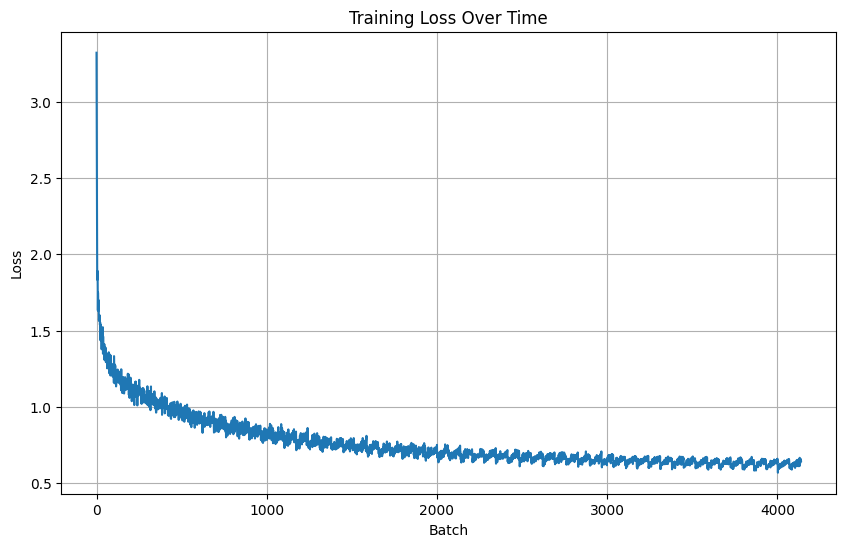

In [11]:
# Define model hyperparameters
alphabet_size = 27
embed_dim = 64
hidden_size = 128
num_layers = 1
epochs = 60
batch_size = 128

# Display training configuration
print(f"Vocabulary size: {len(vocab)} words")
print(f"Training with {epochs} epochs, batch size {batch_size}")

# Create model instance with specified architecture
model = autocompleteModel(
    alphabet_size=alphabet_size,
    embed_dim=embed_dim,
    hidden_size=hidden_size,
    num_layers=num_layers
)

# Calculate and display model complexity
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

# Execute training process
model.trainModel(
    vocab=vocab,
    epochs=epochs,
    batch_size=batch_size
)

# Store the trained model as the best model
best_model = model

In [13]:
test_samples = [
    # Original samples
    "univ", "math", "neur", "engin", "comp", "prog", "scie", "tech",
    
    # Additional challenging samples
    "phys", "chem", "biol", "psych", "phil", "hist", "econ", "poli",
    "algo", "data", "mach", "arti", "soft", "hard", "netw", "syst",
    "analy", "stat", "calc", "geom", "trig", "alge", "numb", "prob",
    "theo", "prac", "expe", "rese", "stud", "proj", "work", "task",
    "solv", "opti", "effi", "perf", "test", "vali", "veri", "impl",
    
    # Complex and challenging examples
    "biochem", "quantum", "environ", "micro", "macro", "nano", "cyber",
    "neuro", "astro", "geo", "hydro", "electr", "mechan", "thermo",
    "crypto", "viral", "bacte", "molec", "atom", "proto", "synth",
    "struct", "dynam", "kinetic", "static", "elastic", "plastic", "graph",
    "matrix", "vector", "scalar", "tensor", "complex", "simple", "linear",
    "nonlin", "finite", "infin", "contin", "discr", "random", "determ",
    "optim", "maxim", "minim", "constrain", "unconstrain", "global", "local",
    "approx", "exact", "numeric", "symbol", "analog", "digit", "binary"
]

print(f"\nTesting autocompletion on {len(test_samples)} samples:")

results = best_model.autocomplete(test_samples, temperature=0.0000001)
for sample, result in zip(test_samples, results):
    print(f"{sample} -> {result}")

print("\nModel ready for evaluation!")


Testing autocompletion on 104 samples:
univ -> universal
math -> mathematicall
neur -> neural
engin -> engineer
comp -> complete
prog -> programmers
scie -> sciences
tech -> techniques
phys -> physio
chem -> chemical
biol -> biology
psych -> psychological
phil -> phillips
hist -> historic
econ -> economic
poli -> policy
algo -> algorithm
data -> databases
mach -> machine
arti -> artist
soft -> software
hard -> hard
netw -> networks
syst -> system
analy -> analysis
stat -> statutory
calc -> calculator
geom -> geometry
trig -> trigger
alge -> algeria
numb -> number
prob -> probability
theo -> theories
prac -> practices
expe -> experiments
rese -> reservoir
stud -> studios
proj -> projectors
work -> works
task -> task
solv -> solve
opti -> optimization
effi -> efficient
perf -> performer
test -> testing
vali -> validation
veri -> verification
impl -> implemented
biochem -> biochem
quantum -> quantum
environ -> environments
micro -> microsoft
macro -> macro
nano -> nano
cyber -> cyber
neu